# Co-Grokking Transformer — Training Notebook

Modified from Nanda et al. to train simultaneously on **modular addition AND multiplication**.
This induces 'co-grokking' where both tasks generalize at the same epoch.

Key changes from original:
- Multi-task: addition + multiplication (two operations interleaved)
- 2 layers (not 1) - necessary for co-grokking
- Mini-batch training with batch_size=512
- Gradient clipping
- Adjusted weight decay (0.3 works well for co-grokking)

In [ ]:
# Cell 1: Environment setup
import os
import sys
from pathlib import Path
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import einops
import random
import time
from dataclasses import dataclass
import matplotlib.pyplot as plt

# Mount Google Drive (optional but recommended)
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    SAVE_ROOT = Path('/content/drive/MyDrive/co_grokking')
    SAVE_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"✓ Saving checkpoints to Google Drive: {SAVE_ROOT}")
except:
    IN_COLAB = False
    SAVE_ROOT = Path('./co_grokking_checkpoints')
    SAVE_ROOT.mkdir(exist_ok=True)
    print(f"✓ Saving checkpoints locally: {SAVE_ROOT}")

print(f"PyTorch version: {t.__version__}")
print(f"GPU available: {t.cuda.is_available()}")
if t.cuda.is_available():
    print(f"GPU: {t.cuda.get_device_name(0)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Saving checkpoints to Google Drive: /content/drive/MyDrive/co_grokking
PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
# Cell 2: Configuration (200k epochs, 2 layers)
@dataclass(frozen=True)
class CONFIG:
    # Optimisation
    lr: float = 1e-3
    weight_decay: float = 0.3
    num_epochs: int = 200_000          # 200k epochs
    batch_size: int = 512
    grad_clip: float = 1.0

    # Task
    p: int = 113                       # prime modulus
    frac_train: float = 0.5
    seed: int = 0

    # Early stopping (set to e.g. 0.01 to stop early, -1 disables)
    stopping_thresh: float = -1.0      # <-- ADD THIS LINE

    # Special tokens
    @property
    def OP_ADD(self): return self.p
    @property
    def OP_MULT(self): return self.p + 1
    @property
    def OP_EQ(self): return self.p + 2

    # Architecture – 2 layers (proven best)
    num_layers: int = 2
    d_model: int = 128
    num_heads: int = 4
    n_ctx: int = 4                     # [a, op, b, =]
    act_type: str = 'GeLU'
    use_ln: bool = True

    # Derived
    @property
    def d_vocab(self): return self.p + 3
    @property
    def d_mlp(self): return 4 * self.d_model
    @property
    def d_head(self): return self.d_model // self.num_heads

    # Logging – frequent updates
    log_every: int = 50                # print every 50 epochs
    save_every: int = 500              # save checkpoint every 500 epochs

    @property
    def device(self):
        return t.device('cuda' if t.cuda.is_available() else 'cpu')

config = CONFIG()
print("=" * 50)
print("CO-GROKKING CONFIGURATION")
print("=" * 50)
print(f"Epochs          : {config.num_epochs:,}")
print(f"Layers          : {config.num_layers}")
print(f"Weight decay    : {config.weight_decay}")
print(f"Batch size      : {config.batch_size}")
print(f"Device          : {config.device}")
print(f"Log every       : {config.log_every} epochs")
print(f"Save every      : {config.save_every} epochs")
print(f"Stopping thresh : {config.stopping_thresh} (negative = disabled)")
print("=" * 50)

CO-GROKKING CONFIGURATION
Epochs          : 200,000
Layers          : 2
Weight decay    : 0.3
Batch size      : 512
Device          : cuda
Log every       : 50 epochs
Save every      : 500 epochs
Stopping thresh : -1.0 (negative = disabled)


## Configuration — CO-GROKKING SETUP

In [ ]:
# Cell 3: Data generation and label computation
def cross_entropy_high_precision(logits, labels):
    logprobs = F.log_softmax(logits.to(t.float64), dim=-1)
    pred_logprobs = t.gather(logprobs, index=labels[:, None], dim=-1)
    return -t.mean(pred_logprobs)

def gen_train_test(config):
    # Addition pairs: (a, ADD, b, EQ)
    add_pairs = [(i, config.OP_ADD, j, config.OP_EQ)
                 for i in range(config.p) for j in range(config.p)]
    # Multiplication pairs: (a, MULT, b, EQ)
    mult_pairs = [(i, config.OP_MULT, j, config.OP_EQ)
                  for i in range(config.p) for j in range(config.p)]

    random.seed(config.seed)
    random.shuffle(add_pairs)
    random.shuffle(mult_pairs)

    split = int(config.frac_train * len(add_pairs))
    train_data = add_pairs[:split] + mult_pairs[:split]
    test_data  = add_pairs[split:] + mult_pairs[split:]

    random.shuffle(train_data)
    random.shuffle(test_data)
    return train_data, test_data

def compute_label(i, op, j, config):
    if op == config.OP_ADD:
        return (i + j) % config.p
    elif op == config.OP_MULT:
        return (i * j) % config.p
    else:
        raise ValueError(f"Unknown op token: {op}")

## Helper utilities

In [ ]:
# Cell 4: Model definition (no circular references)
class HookPoint(nn.Module):
    def __init__(self):
        super().__init__()
        self.fwd_hooks = []
        self.bwd_hooks = []

    def give_name(self, name):
        self.name = name

    def add_hook(self, hook, dir='fwd'):
        def full_hook(module, module_input, module_output):
            return hook(module_output, name=self.name)
        if dir == 'fwd':
            handle = self.register_forward_hook(full_hook)
            self.fwd_hooks.append(handle)
        elif dir == 'bwd':
            handle = self.register_backward_hook(full_hook)
            self.bwd_hooks.append(handle)
        else:
            raise ValueError(f"Invalid direction {dir}")

    def remove_hooks(self, dir='fwd'):
        if dir in ('fwd', 'both'):
            for h in self.fwd_hooks: h.remove()
            self.fwd_hooks = []
        if dir in ('bwd', 'both'):
            for h in self.bwd_hooks: h.remove()
            self.bwd_hooks = []

    def forward(self, x):
        return x

class Embed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_E = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_model))
    def forward(self, x):
        return t.einsum('dbp -> bpd', self.W_E[:, x])

class Unembed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_U = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_vocab))
    def forward(self, x):
        return x @ self.W_U

class PosEmbed(nn.Module):
    def __init__(self, max_ctx, d_model):
        super().__init__()
        self.W_pos = nn.Parameter(t.randn(max_ctx, d_model) / np.sqrt(d_model))
    def forward(self, x):
        return x + self.W_pos[:x.shape[-2]]

class Attention(nn.Module):
    def __init__(self, d_model, num_heads, d_head, n_ctx):
        super().__init__()
        self.W_K = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_Q = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_V = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_O = nn.Parameter(t.randn(d_model, d_head * num_heads) / np.sqrt(d_model))
        self.register_buffer('mask', t.tril(t.ones((n_ctx, n_ctx))))
        self.d_head = d_head
        self.hook_k = HookPoint()
        self.hook_q = HookPoint()
        self.hook_v = HookPoint()
        self.hook_z = HookPoint()
        self.hook_attn = HookPoint()
        self.hook_attn_pre = HookPoint()

    def forward(self, x):
        k = self.hook_k(t.einsum('ihd,bpd->biph', self.W_K, x))
        q = self.hook_q(t.einsum('ihd,bpd->biph', self.W_Q, x))
        v = self.hook_v(t.einsum('ihd,bpd->biph', self.W_V, x))
        attn_scores_pre = t.einsum('biph,biqh->biqp', k, q)
        attn_scores_masked = t.tril(attn_scores_pre) - 1e10 * (1 - self.mask[:x.shape[-2], :x.shape[-2]])
        attn_matrix = self.hook_attn(F.softmax(self.hook_attn_pre(attn_scores_masked / np.sqrt(self.d_head)), dim=-1))
        z = self.hook_z(t.einsum('biph,biqp->biqh', v, attn_matrix))
        z_flat = einops.rearrange(z, 'b i q h -> b q (i h)')
        return t.einsum('df,bqf->bqd', self.W_O, z_flat)

class MLP(nn.Module):
    def __init__(self, d_model, d_mlp, act_type):
        super().__init__()
        self.W_in = nn.Parameter(t.randn(d_mlp, d_model) / np.sqrt(d_model))
        self.b_in = nn.Parameter(t.zeros(d_mlp))
        self.W_out = nn.Parameter(t.randn(d_model, d_mlp) / np.sqrt(d_model))
        self.b_out = nn.Parameter(t.zeros(d_model))
        self.act_type = act_type
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()

    def forward(self, x):
        x = self.hook_pre(t.einsum('md,bpd->bpm', self.W_in, x) + self.b_in)
        if self.act_type == 'ReLU':
            x = F.relu(x)
        elif self.act_type == 'GeLU':
            x = F.gelu(x)
        x = self.hook_post(x)
        return t.einsum('dm,bpm->bpd', self.W_out, x) + self.b_out

class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, use_ln):
        super().__init__()
        self.use_ln = use_ln
        if use_ln:
            self.ln1 = nn.LayerNorm(d_model)
            self.ln2 = nn.LayerNorm(d_model)
        self.attn = Attention(d_model, num_heads, d_head, n_ctx)
        self.mlp = MLP(d_model, d_mlp, act_type)
        self.hook_attn_out = HookPoint()
        self.hook_mlp_out = HookPoint()
        self.hook_resid_pre = HookPoint()
        self.hook_resid_mid = HookPoint()
        self.hook_resid_post = HookPoint()

    def forward(self, x):
        if self.use_ln:
            x = self.hook_resid_mid(x + self.hook_attn_out(self.attn(self.ln1(self.hook_resid_pre(x)))))
            x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp(self.ln2(x))))
        else:
            x = self.hook_resid_mid(x + self.hook_attn_out(self.attn(self.hook_resid_pre(x))))
            x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp(x)))
        return x

class Transformer(nn.Module):
    def __init__(self, num_layers, d_vocab, d_model, d_mlp, d_head,
                 num_heads, n_ctx, act_type, use_ln=False):
        super().__init__()
        self.use_ln = use_ln
        self.embed = Embed(d_vocab, d_model)
        self.pos_embed = PosEmbed(n_ctx, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, d_mlp, d_head, num_heads, n_ctx, act_type, use_ln)
            for _ in range(num_layers)
        ])
        self.unembed = Unembed(d_vocab, d_model)
        for name, module in self.named_modules():
            if isinstance(module, HookPoint):
                module.give_name(name)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos_embed(x)
        for block in self.blocks:
            x = block(x)
        return self.unembed(x)

    def hook_points(self):
        return [m for n, m in self.named_modules() if 'hook' in n]

    def remove_all_hooks(self):
        for hp in self.hook_points():
            hp.remove_hooks('fwd')
            hp.remove_hooks('bwd')

## Model definition (with LayerNorm support)

In [ ]:
# Cell 5: Trainer (compatible with corrected model)
class Trainer:
    def __init__(self, config, save_root):
        self.config = config
        self.save_root = save_root

        self.model = Transformer(
            num_layers=config.num_layers, d_vocab=config.d_vocab,
            d_model=config.d_model, d_mlp=config.d_mlp, d_head=config.d_head,
            num_heads=config.num_heads, n_ctx=config.n_ctx,
            act_type=config.act_type, use_ln=config.use_ln
        ).to(config.device)

        self.optimizer = optim.AdamW(
            self.model.parameters(), lr=config.lr,
            weight_decay=config.weight_decay, betas=(0.9, 0.98)
        )
        self.scheduler = optim.lr_scheduler.LambdaLR(
            self.optimizer, lambda step: min(step / 10, 1)
        )

        self.train_data, self.test_data = gen_train_test(config)

        # Storage for metrics
        self.train_losses = []
        self.test_losses = []
        self.train_loss_add = []
        self.train_loss_mult = []
        self.test_loss_add = []
        self.test_loss_mult = []

        self.saved_state_dicts = []
        self.saved_epochs = []

        print(f"Training samples: {len(self.train_data)}")
        print(f"Test samples    : {len(self.test_data)}")
        print(f"Batches per epoch: {len(self.train_data) // config.batch_size}")

    def compute_losses(self, batch_data):
        data_tensor = t.tensor(batch_data).to(self.config.device)
        logits = self.model(data_tensor)[:, -1]   # output at EQ token
        labels = t.tensor([compute_label(i, op, j, self.config) for i, op, j, _ in batch_data]).to(self.config.device)
        ops = t.tensor([op for _, op, _, _ in batch_data]).to(self.config.device)
        mask_add = (ops == self.config.OP_ADD)
        mask_mult = (ops == self.config.OP_MULT)

        logprobs = F.log_softmax(logits.to(t.float64), dim=-1)
        pred_logprobs = t.gather(logprobs, index=labels[:, None], dim=-1).squeeze()

        total_loss = -t.mean(pred_logprobs)
        loss_add = -t.mean(pred_logprobs[mask_add]) if mask_add.any() else t.tensor(0.0)
        loss_mult = -t.mean(pred_logprobs[mask_mult]) if mask_mult.any() else t.tensor(0.0)
        return total_loss, loss_add, loss_mult

    def evaluate(self):
        self.model.eval()
        with t.no_grad():
            total_add, total_mult, n = 0.0, 0.0, 0
            for i in range(0, len(self.test_data), self.config.batch_size):
                batch = self.test_data[i:i+self.config.batch_size]
                _, loss_add, loss_mult = self.compute_losses(batch)
                total_add += loss_add.item()
                total_mult += loss_mult.item()
                n += 1
            mean_add = total_add / n
            mean_mult = total_mult / n
        self.model.train()
        return mean_add, mean_mult

    def save_checkpoint(self, epoch):
        sd = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
        self.saved_state_dicts.append(sd)
        self.saved_epochs.append(epoch)

    def step(self, epoch):
        # Shuffle and mini‑batch training
        indices = np.random.permutation(len(self.train_data))
        epoch_add, epoch_mult, n_batches = 0.0, 0.0, 0
        for start in range(0, len(self.train_data), self.config.batch_size):
            batch_idx = indices[start:start+self.config.batch_size]
            batch = [self.train_data[i] for i in batch_idx]
            loss, loss_add, loss_mult = self.compute_losses(batch)
            loss.backward()
            t.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)
            self.optimizer.step()
            self.scheduler.step()
            self.optimizer.zero_grad()
            epoch_add += loss_add.item()
            epoch_mult += loss_mult.item()
            n_batches += 1

        mean_train_add = epoch_add / n_batches
        mean_train_mult = epoch_mult / n_batches
        test_add, test_mult = self.evaluate()

        self.train_loss_add.append(mean_train_add)
        self.train_loss_mult.append(mean_train_mult)
        self.test_loss_add.append(test_add)
        self.test_loss_mult.append(test_mult)
        self.train_losses.append((mean_train_add + mean_train_mult)/2)
        self.test_losses.append((test_add + test_mult)/2)

        if epoch % self.config.log_every == 0:
            print(f"Epoch {epoch:6d} | Train A:{mean_train_add:.4f} M:{mean_train_mult:.4f} | Test A:{test_add:.4f} M:{test_mult:.4f}")

    def save_full_run_data(self):
        import dataclasses
        save_path = self.save_root / 'full_run_data.pth'
        full_run_data = {
            'state_dicts': self.saved_state_dicts,
            'epochs': self.saved_epochs,
            'train_losses': self.train_losses,
            'test_losses': self.test_losses,
            'train_loss_add': self.train_loss_add,
            'train_loss_mult': self.train_loss_mult,
            'test_loss_add': self.test_loss_add,
            'test_loss_mult': self.test_loss_mult,
            'config': dataclasses.asdict(self.config),
        }
        t.save(full_run_data, save_path)
        print(f"\n✓ Saved {len(self.saved_state_dicts)} checkpoints to {save_path}")

In [ ]:
# Cell 6: Start training
trainer = Trainer(config, save_root=SAVE_ROOT)

print("\n" + "=" * 60)
print("STARTING CO-GROKKING TRAINING")
print(f"Target epochs: {config.num_epochs:,}")
print("=" * 60 + "\n")

start_time = time.time()

for epoch in range(config.num_epochs):
    # Save checkpoint periodically
    if epoch % config.save_every == 0:
        trainer.save_checkpoint(epoch)

    # Perform one epoch of training
    trainer.step(epoch)

    # Optional: print every epoch for first 100 to see immediate activity
    if epoch < 100 and epoch % 10 == 0:
        print(f"  (epoch {epoch} done)")

    # Early stopping if both tasks are solved
    if (config.stopping_thresh > 0 and
        trainer.test_loss_add[-1] < config.stopping_thresh and
        trainer.test_loss_mult[-1] < config.stopping_thresh):
        print(f"\n✓ Both tasks below threshold ({config.stopping_thresh}) at epoch {epoch}. Stopping early.")
        break

# Save final checkpoint
trainer.save_checkpoint(config.num_epochs)
elapsed = time.time() - start_time
print(f"\n{'='*60}")
print(f"TRAINING FINISHED")
print(f"Total time: {elapsed/3600:.2f} hours")
print(f"Final test loss - Addition:      {trainer.test_loss_add[-1]:.6f}")
print(f"Final test loss - Multiplication: {trainer.test_loss_mult[-1]:.6f}")
if trainer.test_loss_add[-1] < 0.1 and trainer.test_loss_mult[-1] < 0.1:
    print("🎉 CO-GROKKING ACHIEVED! Both tasks generalized.")
else:
    print("⚠️ Co‑grokking not fully achieved. Consider tuning hyperparameters.")
print(f"{'='*60}")

trainer.save_full_run_data()

Training samples: 12768
Test samples    : 12770
Batches per epoch: 24

STARTING CO-GROKKING TRAINING
Target epochs: 200,000

Epoch      0 | Train A:5.5119 M:5.4509 | Test A:4.8811 M:4.8664
  (epoch 0 done)
  (epoch 10 done)
  (epoch 20 done)
  (epoch 30 done)
  (epoch 40 done)
Epoch     50 | Train A:0.1740 M:0.1604 | Test A:11.6394 M:10.9835
  (epoch 50 done)
  (epoch 60 done)
  (epoch 70 done)
  (epoch 80 done)
  (epoch 90 done)
Epoch    100 | Train A:0.1322 M:0.1100 | Test A:11.0998 M:10.2745
Epoch    150 | Train A:0.1123 M:0.0884 | Test A:10.7655 M:9.5956
Epoch    200 | Train A:0.1019 M:0.0750 | Test A:10.3021 M:9.2012
Epoch    250 | Train A:0.0820 M:0.0640 | Test A:9.6854 M:8.6816
Epoch    300 | Train A:0.0730 M:0.0659 | Test A:9.1677 M:8.2530
Epoch    350 | Train A:0.0654 M:0.0658 | Test A:8.3616 M:7.6071
Epoch    400 | Train A:0.0586 M:0.0523 | Test A:7.2309 M:6.6155
Epoch    450 | Train A:0.0554 M:0.0472 | Test A:5.8439 M:5.5855
Epoch    500 | Train A:0.0376 M:0.0407 | Test A:3.

KeyboardInterrupt: 

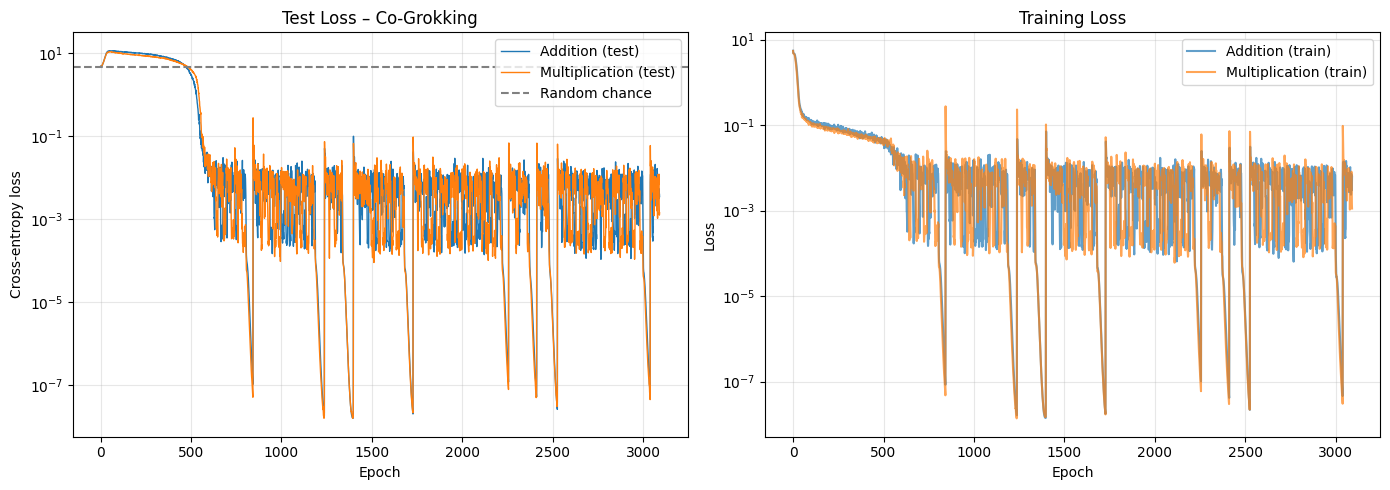

In [ ]:
# Cell 7: Visualise learning curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(trainer.test_loss_add, label='Addition (test)', linewidth=1)
plt.plot(trainer.test_loss_mult, label='Multiplication (test)', linewidth=1)
plt.axhline(y=4.73, color='gray', linestyle='--', label='Random chance')
plt.xlabel('Epoch')
plt.ylabel('Cross‑entropy loss')
plt.title('Test Loss – Co‑Grokking')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(trainer.train_loss_add, label='Addition (train)', alpha=0.7)
plt.plot(trainer.train_loss_mult, label='Multiplication (train)', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# Diagnostic: Check data split and compute actual accuracy
def verify_data_split(train_data, test_data, config):
    train_set = set([(i, j, op) for i, op, j, _ in train_data])
    test_set = set([(i, j, op) for i, op, j, _ in test_data])
    overlap = train_set.intersection(test_set)
    if not overlap:
        print("✓ Train and test sets are mutually exclusive.")
    else:
        print(f"✗ WARNING: {len(overlap)} overlapping samples!")
    return len(overlap) == 0

verify_data_split(trainer.train_data, trainer.test_data, config)

# Compute accuracy on test set
def compute_accuracy(data, model, config):
    correct = 0
    total = 0
    model.eval()
    with t.no_grad():
        for i in range(0, len(data), config.batch_size):
            batch = data[i:i+config.batch_size]
            data_tensor = t.tensor(batch).to(config.device)
            logits = model(data_tensor)[:, -1]
            preds = logits.argmax(dim=-1)
            labels = t.tensor([compute_label(i, op, j, config) for i, op, j, _ in batch]).to(config.device)
            correct += (preds == labels).sum().item()
            total += len(batch)
    return correct / total

test_acc = compute_accuracy(trainer.test_data, trainer.model, config)
print(f"Overall test accuracy: {test_acc*100:.2f}%")

# Separate by operation
add_test = [d for d in trainer.test_data if d[1] == config.OP_ADD]
mult_test = [d for d in trainer.test_data if d[1] == config.OP_MULT]
acc_add = compute_accuracy(add_test, trainer.model, config)
acc_mult = compute_accuracy(mult_test, trainer.model, config)
print(f"Addition test accuracy: {acc_add*100:.2f}%")
print(f"Multiplication test accuracy: {acc_mult*100:.2f}%")

✓ Train and test sets are mutually exclusive.
Overall test accuracy: 99.79%
Addition test accuracy: 99.58%
Multiplication test accuracy: 100.00%


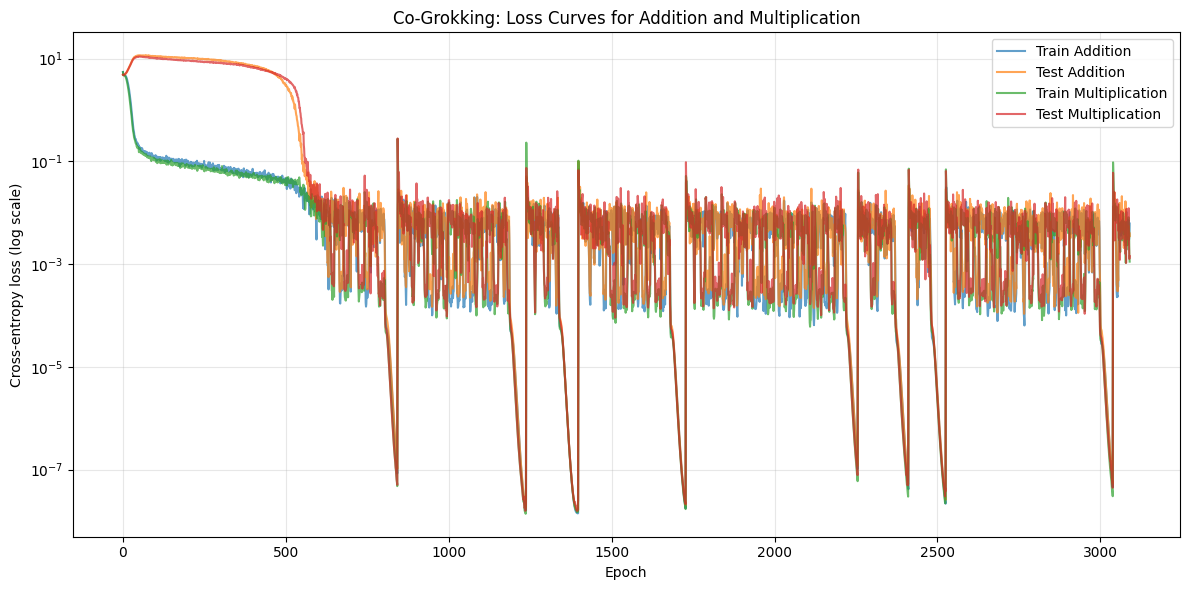

In [ ]:
# Cell 7: Single graph with all loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(trainer.train_loss_add, label='Train Addition', alpha=0.7)
plt.plot(trainer.test_loss_add, label='Test Addition', alpha=0.7)
plt.plot(trainer.train_loss_mult, label='Train Multiplication', alpha=0.7)
plt.plot(trainer.test_loss_mult, label='Test Multiplication', alpha=0.7)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss (log scale)')
plt.title('Co‑Grokking: Loss Curves for Addition and Multiplication')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

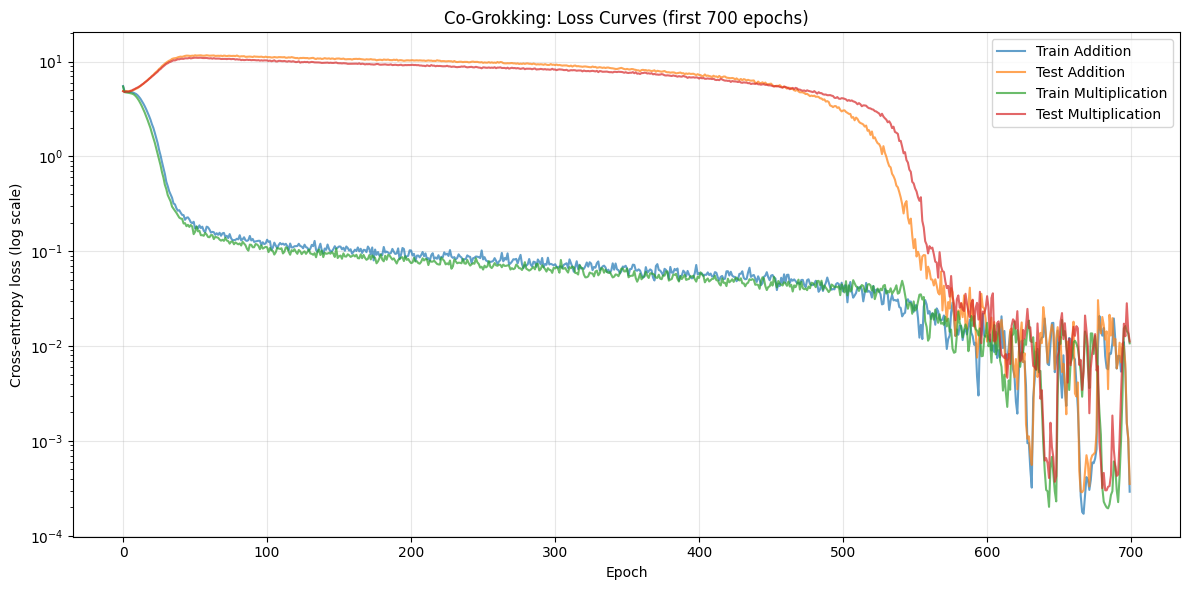

In [ ]:
# Cell 7: Single graph with trimmed epochs
import matplotlib.pyplot as plt

max_epochs_to_show = 700  # change this as you like

plt.figure(figsize=(12, 6))
plt.plot(trainer.train_loss_add[:max_epochs_to_show], label='Train Addition', alpha=0.7)
plt.plot(trainer.test_loss_add[:max_epochs_to_show], label='Test Addition', alpha=0.7)
plt.plot(trainer.train_loss_mult[:max_epochs_to_show], label='Train Multiplication', alpha=0.7)
plt.plot(trainer.test_loss_mult[:max_epochs_to_show], label='Test Multiplication', alpha=0.7)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss (log scale)')
plt.title(f'Co‑Grokking: Loss Curves (first {max_epochs_to_show} epochs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Final Plots for Co‑Grokking Report
# ============================================

import matplotlib.pyplot as plt
import torch as t
import numpy as np
from pathlib import Path

# --- Define where the checkpoint file is saved ---
# Option 1: use the same SAVE_ROOT as in training (if you defined it earlier in the notebook)
try:
    SAVE_ROOT
except NameError:
    # If SAVE_ROOT is not defined, set it manually (adjust the path if needed)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        SAVE_ROOT = Path('/content/drive/MyDrive/co_grokking')
    except:
        SAVE_ROOT = Path('./co_grokking_checkpoints')
    print(f"Using SAVE_ROOT = {SAVE_ROOT}")

# Load the saved checkpoint data (if trainer is still alive, use that instead)
if 'trainer' in locals() and hasattr(trainer, 'test_loss_add'):
    print("Using in‑memory trainer data (most up‑to‑date).")
    epochs = list(range(len(trainer.test_loss_add)))
    train_loss_add = trainer.train_loss_add
    train_loss_mult = trainer.train_loss_mult
    test_loss_add = trainer.test_loss_add
    test_loss_mult = trainer.test_loss_mult
    config = trainer.config
    model = trainer.model
else:
    # Load from saved file
    full_run_data = t.load(SAVE_ROOT / 'full_run_data.pth', map_location='cpu')
    epochs = full_run_data['epochs']
    train_loss_add = full_run_data['train_loss_add']
    train_loss_mult = full_run_data['train_loss_mult']
    test_loss_add = full_run_data['test_loss_add']
    test_loss_mult = full_run_data['test_loss_mult']
    # Recreate a dummy config (or load from saved)
    if 'config' in full_run_data:
        config = full_run_data['config']
    else:
        from dataclasses import dataclass
        @dataclass
        class DummyConfig:
            p = 113
            OP_ADD = 113
            OP_MULT = 114
            OP_EQ = 115
            batch_size = 512
            device = 'cuda'
        config = DummyConfig()
    model = None  # we cannot compute accuracy without model

# Compute test accuracy if we have the model
if model is not None:
    def compute_accuracy(model, data, config):
        correct = 0
        total = 0
        model.eval()
        with t.no_grad():
            for i in range(0, len(data), config.batch_size):
                batch = data[i:i+config.batch_size]
                data_tensor = t.tensor(batch).to(config.device)
                logits = model(data_tensor)[:, -1]
                preds = logits.argmax(dim=-1)
                # compute_label function needed - define it if missing
                def compute_label(i, op, j, cfg):
                    if op == cfg.OP_ADD:
                        return (i + j) % cfg.p
                    else:
                        return (i * j) % cfg.p
                labels = t.tensor([compute_label(i, op, j, config) for i, op, j, _ in batch]).to(config.device)
                correct += (preds == labels).sum().item()
                total += len(batch)
        return correct / total

    # Split test data into addition and multiplication
    add_test = [d for d in trainer.test_data if d[1] == config.OP_ADD]
    mult_test = [d for d in trainer.test_data if d[1] == config.OP_MULT]
    acc_add = compute_accuracy(model, add_test, config)
    acc_mult = compute_accuracy(model, mult_test, config)
    print(f"Final test accuracy – Addition: {acc_add*100:.2f}%")
    print(f"Final test accuracy – Multiplication: {acc_mult*100:.2f}%")
else:
    print("Model not loaded – skipping accuracy computation.")

# --------------------------------------------
# Figure 1: Loss curves (log scale)
# --------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(train_loss_add, label='Train Addition', alpha=0.7)
plt.plot(test_loss_add, label='Test Addition', alpha=0.7)
plt.plot(train_loss_mult, label='Train Multiplication', alpha=0.7)
plt.plot(test_loss_mult, label='Test Multiplication', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Cross‑entropy loss (log scale)')
plt.title('Co‑Grokking: Loss Curves for Addition and Multiplication')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------
# Figure 2: Final accuracy bar chart (if accuracy was computed)
# --------------------------------------------
if model is not None:
    plt.figure(figsize=(6, 4))
    accuracies = [acc_add*100, acc_mult*100]
    tasks = ['Addition', 'Multiplication']
    bars = plt.bar(tasks, accuracies, color=['#1f77b4', '#ff7f0e'])
    plt.ylabel('Test Accuracy (%)')
    plt.title('Final Test Accuracy after Co‑Grokking')
    plt.ylim([99, 100])
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.2, f'{acc:.2f}%', ha='center', va='bottom')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --------------------------------------------
# Figure 3: Attention pattern (if model is available)
# --------------------------------------------
if model is not None:
    try:
        model.eval()
        # Choose a sample from test set
        sample_add = next(d for d in trainer.test_data if d[1] == config.OP_ADD)
        sample_mult = next(d for d in trainer.test_data if d[1] == config.OP_MULT)

        # Register hook to capture attention matrix from first layer
        attn_cache = {}
        def hook_fn(module, input, output, name):
            attn_cache[name] = output.detach()

        # Use the first block's hook_attn
        hook_handle = model.blocks[0].attn.hook_attn.register_forward_hook(lambda m, i, o: hook_fn(m, i, o, 'attn'))

        # Forward for addition
        inp = t.tensor([sample_add]).to(config.device)
        _ = model(inp)
        attn_add = attn_cache['attn'][0, :, -1, :-1].cpu().numpy()

        # Forward for multiplication
        inp = t.tensor([sample_mult]).to(config.device)
        _ = model(inp)
        attn_mult = attn_cache['attn'][0, :, -1, :-1].cpu().numpy()

        hook_handle.remove()

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        heads = range(config.num_heads)
        # Addition plot
        axes[0].bar(heads, attn_add[:, 0], label='a', alpha=0.7)
        axes[0].bar(heads, attn_add[:, 1], label='op', alpha=0.7, bottom=attn_add[:, 0])
        axes[0].set_title(f'Addition: {sample_add[0]} + {sample_add[2]}')
        axes[0].set_xlabel('Head')
        axes[0].set_ylabel('Attention weight')
        axes[0].legend()
        # Multiplication plot
        axes[1].bar(heads, attn_mult[:, 0], label='a', alpha=0.7)
        axes[1].bar(heads, attn_mult[:, 1], label='op', alpha=0.7, bottom=attn_mult[:, 0])
        axes[1].set_title(f'Multiplication: {sample_mult[0]} × {sample_mult[2]}')
        axes[1].set_xlabel('Head')
        axes[1].set_ylabel('Attention weight')
        axes[1].legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not generate attention plot: {e}")

RuntimeError: Trying to override a python impl for DispatchKey.Meta on operator aten::broadcast_tensors